Import required libraries for neural network:

In [1]:
import tensorflow as tf
import pandas as pd
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

Splitting data for 80% train and 20% test for validation:

In [2]:
df = pd.read_csv(r'data/othello_training_data_fixed.csv')

In [3]:
X = df.drop(columns=['score']).values
y = df['score'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model and layers:

In [4]:
model = models.Sequential([
    layers.Input(shape=(36,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [5]:
model.compile(optimizer="adam", loss="mse", metrics=['mae'])

In [6]:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), batch_size=64)

Epoch 1/50
3994/3994 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0522 - mae: 0.1619 - val_loss: 0.0466 - val_mae: 0.1508
Epoch 2/50
3994/3994 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0456 - mae: 0.1488 - val_loss: 0.0455 - val_mae: 0.1485
Epoch 3/50
3994/3994 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0444 - mae: 0.1467 - val_loss: 0.0447 - val_mae: 0.1479
Epoch 4/50
3994/3994 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0437 - mae: 0.1457 - val_loss: 0.0441 - val_mae: 0.1466
Epoch 5/50
3994/3994 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.0433 - mae: 0.1451 - val_loss: 0.0436 - val_mae: 0.1455
Epoch 6/50
3994/3994 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0428 - mae: 0.1447 - val_loss: 0.0430 - val_mae: 0.1453
Epoch 7/50
3994/3994 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0424 - mae: 0.1441 - val_loss: 0.0427 - val_mae: 0.1450
Epoch 8/50
3994/3994 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0421 - mae: 0.1436 - val_loss: 0.0424 - val_mae: 0.1443
Epoch 9/50
3994/3994 ━━━━━━━━━━━

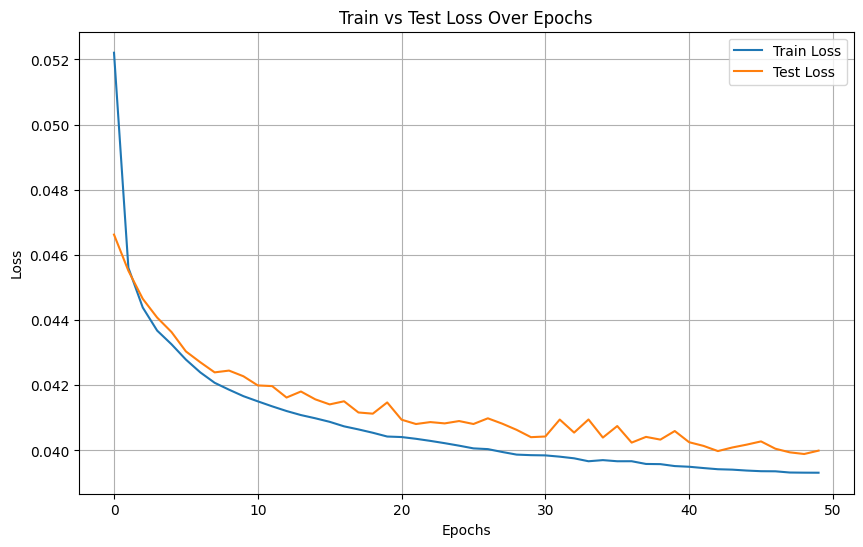

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Train vs Test Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [8]:
model.save('othello_model.keras')